In [13]:
# Check if autoreload is loaded and load/reload accordingly
try:
    %reload_ext autoreload
except Exception:
    %load_ext autoreload
%autoreload 2
%matplotlib widget


# Basic useful imports
import sys
from pathlib import Path
import h5py

sys.setrecursionlimit(10000)

# Data manipulation
import numpy as np
from scipy.ndimage.filters import uniform_filter1d

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import ScalarFormatter



from dyn_cond_fig_functions import *

# Clustering stuff
from itertools import cycle
# plt.cm.tab20.colors

# From alens_analysis.py
import alens_analysis as aa
from alens_analysis import cluster_analysis as cla

# Locations
ws_path = Path("/home/alamson/DATA/Chromatin/")
mnt_path = Path.home() / "projects/DATA/Chromatin/"
ceph_path = Path.home() / "ceph/DATA/Chromatin/"

/tmp/ipykernel_4089114/3608549845.py:19: DeprecationWarning: Please import `uniform_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import uniform_filter1d


### Style settings

In [14]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 2,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    "font.sans-serif": "DejaVu Sans",
    "text.usetex": False,
    "mathtext.fontset": "cm",
}
plt.style.use(graph_sty)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))

plt.rcParams["image.cmap"] = "YlOrRd"

In [3]:
# Consistent settings
ss_ind = 1
end_ind = None
start_bead = 0
end_bead = None
part_min = 40

# System parameters
L_tot = 1600
L_tot_um = 16.0

# Diffusion time
visc = 1.0 # pN*s/um^2
b_diam = 0.01 # um
kbT = .00411 # pN*um
bead_diff = kbT / (3 * np.pi * visc * b_diam) # um^2/s
diff_time = b_diam**3*3.*np.pi*visc / (6.*kbT) # s
print(f"Diffusion time: {diff_time:.5f} s")

Diffusion time: 0.00038 s


# Functions

In [4]:
def get_cluster_trees_from_h5file(
    h5_file, cluster_similarity_threshold=0.4, nskip=10, part_min=0
):
    clusters = []
    with h5py.File(h5_file, "r") as h5_data:
        cluster_grp = h5_data["clusters"]
        time_grp_list = sorted(cluster_grp.values(), key=lambda x: x.attrs["time"])
        for tg in time_grp_list:
            clust_grp = [cla.Cluster(h5_data=c) for c in tg.values()]
            clust_grp = [clust for clust in clust_grp if len(clust.part_ids) > part_min]
            clusters += [clust_grp]

    root_clusters = cla.find_descendants(
        clusters, thresh=cluster_similarity_threshold, nskip=nskip
    )

    trees = []
    tree_id_gen = aa.helpers.gen_id()
    for root in root_clusters:
        tree = cla.ClusterTree(next(tree_id_gen))
        tree.add_recursive(root)
        trees += [tree]

    return trees


def get_lifetimes(branch_roots, min_time=0, min_length=0):
    lifetime_list = []
    for root in branch_roots:
        if root.time < min_time:  # Skip if the root is too short
            continue
        l_branch = root.get_largest_branch()
        if len(l_branch) < min_length:
            continue
        lifetime_list += [l_branch[0].time - l_branch[-1].time]

    return lifetime_list


def get_time_of_events(branch_roots, min_time=0, min_length=0):
    eventime_list = []
    for root in branch_roots:
        if root.time < min_time:  # Skip if the root is too short
            continue
        l_branch = root.get_largest_branch()
        if len(l_branch) < min_length:
            continue
        eventime_list += [l_branch[0].time]

    return eventime_list


def plot_branches(axarr, full_time_arr, branch_roots, window_size=10, color="tab:blue"):
    time_list = []
    base_color_hsv = mcolors.rgb_to_hsv(color)
    base_color_hsv[2] = 0.9
    color_step = 0.8 / len(branch_roots)

    for i, root in enumerate(branch_roots):
        color_hsv = base_color_hsv.copy()
        color_hsv[2] = base_color_hsv[2] - (color_step * i)
        branch_color = mcolors.hsv_to_rgb(color_hsv)

        l_branch = root.get_largest_branch()
        if len(l_branch) < 20:
            continue
        size_arr = np.zeros(len(l_branch))
        time_arr = np.zeros(len(l_branch))
        for j, clust in enumerate(l_branch):
            size_arr[j] = len(clust.part_ids)
            time_arr[j] = clust.time

        size_arr_smooth = uniform_filter1d(size_arr, size=window_size)
        _ = axarr.plot(
            time_arr, size_arr_smooth, linestyle="-", linewidth=2, color=branch_color
        )
        if i > 0:
            _ = axarr.scatter(
                time_arr[0],
                size_arr_smooth[0],
                marker="o",
                linewidth=2,
                s=100,
                facecolor="none",
                edgecolor=branch_color,
            )

        if root.time == full_time_arr[-1]:
            print("Skipping root")
            # Skip, this is not a real event
            continue
        time_list += [time_arr[0] - time_arr[-1]]
    return time_list


def plot_cluster_size(
    axarr, full_time_arr, branch_roots, window_size=10, color="tab:blue", alpha=1
):
    time_arr_list = []
    size_arr_list = []
    type_list = []

    for i, root in enumerate(branch_roots):
        l_branch = root.get_largest_branch()
        if len(l_branch) < 20:
            continue
        size_arr = np.zeros(len(l_branch))
        time_arr = np.zeros(len(l_branch))
        for j, clust in enumerate(l_branch):
            size_arr[j] = len(clust.part_ids)
            time_arr[j] = clust.time

        size_arr = size_arr[::-1]
        time_arr = time_arr[::-1]

        size_arr_smooth = uniform_filter1d(size_arr, size=window_size)
        _ = axarr.plot(
            time_arr,
            size_arr_smooth,
            linestyle="-",
            linewidth=2,
            color=color,
            alpha=alpha,
        )

        if i > 0:
            _ = axarr.scatter(
                time_arr[-1],
                size_arr_smooth[-1],
                marker="o",
                linewidth=2,
                s=100,
                facecolor="none",
                edgecolor=color,
            )
            type_list.append("M")
        elif size_arr[-1] < 50:
            type_list.append("D")
        else:
            type_list.append("L")

        size_arr_list.append(size_arr)
        time_arr_list.append(time_arr)

    return time_arr_list, size_arr_list, type_list


def plot_large_cluster_sizes(
    axarr, full_time_arr, branch_roots, window_size=10, color="tab:blue", alpha=1
):
    time_arr_list = []
    size_arr_list = []

    for i, root in enumerate(branch_roots):
        l_branch = root.get_largest_branch()
        if len(l_branch) < 20:
            continue
        size_arr = np.zeros(len(l_branch))
        time_arr = np.zeros(len(l_branch))
        for j, clust in enumerate(l_branch):
            size_arr[j] = len(clust.part_ids)
            time_arr[j] = clust.time

        size_arr_smooth = uniform_filter1d(size_arr, size=window_size)[::-1]
        time_arr = time_arr[::-1]
        if i > 0 or root.time < 3600 or size_arr_smooth[-1] < 300:
            continue
            # _ = axarr.scatter(time_arr[-1], size_arr_smooth[-1],  marker='o', linewidth=2, s=100, facecolor="none", edgecolor=color)

        _ = axarr.plot(
            time_arr,
            size_arr_smooth,
            linestyle="-",
            linewidth=2,
            color=color,
            alpha=alpha,
        )

        size_arr_list.append(size_arr_smooth)
        time_arr_list.append(time_arr)

    return time_arr_list, size_arr_list


def plot_no_merge_cluster_sizes(
    axarr, full_time_arr, branch_roots, window_size=10, color="tab:blue", alpha=1
):
    time_arr_list = []
    size_arr_list = []

    for i, root in enumerate(branch_roots):
        l_branch = root.get_largest_branch()
        if len(l_branch) < 20:
            continue
        size_arr = np.zeros(len(l_branch))
        time_arr = np.zeros(len(l_branch))
        for j, clust in enumerate(l_branch):
            size_arr[j] = len(clust.part_ids)
            time_arr[j] = clust.time

        size_arr_smooth = uniform_filter1d(size_arr, size=window_size)[::-1]
        time_arr = time_arr[::-1]
        if i > 0:
            continue
            # _ = axarr.scatter(time_arr[-1], size_arr_smooth[-1],  marker='o', linewidth=2, s=100, facecolor="none", edgecolor=color)

        _ = axarr.plot(
            time_arr,
            size_arr_smooth,
            linestyle="-",
            linewidth=2,
            color=color,
            alpha=alpha,
        )

        size_arr_list.append(size_arr_smooth)
        time_arr_list.append(time_arr)

    return time_arr_list, size_arr_list


def plot_no_dissolve_cluster_sizes(
    axarr, full_time_arr, branch_roots, window_size=10, color="tab:blue", alpha=1
):
    time_arr_list = []
    size_arr_list = []

    for i, root in enumerate(branch_roots):
        l_branch = root.get_largest_branch()
        if len(l_branch) < 20:
            continue
        size_arr = np.zeros(len(l_branch))
        time_arr = np.zeros(len(l_branch))
        for j, clust in enumerate(l_branch):
            size_arr[j] = len(clust.part_ids)
            time_arr[j] = clust.time

        size_arr_smooth = uniform_filter1d(size_arr, size=window_size)[::-1]
        time_arr = time_arr[::-1]
        if size_arr_smooth[-1] < 50:
            continue
            # _ = axarr.scatter(time_arr[-1], size_arr_smooth[-1],  marker='o', linewidth=2, s=100, facecolor="none", edgecolor=color)

        _ = axarr.plot(
            time_arr,
            size_arr_smooth,
            linestyle="-",
            linewidth=2,
            color=color,
            alpha=alpha,
        )

        size_arr_list.append(size_arr_smooth)
        time_arr_list.append(time_arr)

    return time_arr_list, size_arr_list

In [5]:
def plot_contact_kymo(
    fig, ax, time_arr, contact_kymo, contact_type="", vmax=10, label_flag=True
):
    y = np.arange(contact_kymo.shape[0] + 1)
    # Add extra time point
    x = np.append(time_arr, [time_arr[-1] + time_arr[2] - time_arr[1]])
    X, Y = np.meshgrid(x, y)
    c = ax.pcolorfast(X, Y, contact_kymo, vmax=vmax)
    divider = make_axes_locatable(ax)
    # Append axes to the right of ax, with 5% width of ax
    cax = divider.append_axes("top", size="5%", pad=0.05)

    cbar = fig.colorbar(
        c, cax=cax, label=r"Contact probability", orientation="horizontal", pad=0.1
    )
    cbar.ax.xaxis.set_ticks_position("top")
    cbar.ax.xaxis.set_label_position("top")
    # cbar.ax.set_position([.1, 1.02, .8, .02])

    ax.set_ylabel("Bead index")

In [6]:
def plot_kymo_contact_size_graphs(fig, axarr, Ke, Lsep, s, labels_on=True):
    sim_path = (
        ceph_path
        / f"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke{Ke:d}_Pin{Lsep:.1f}um/s{s:d}"
    )
    print(sim_path)

    tableau10_colors = iter(cycle(plt.cm.tab10.colors))

    cluster_similarity_threshold = 0.4
    nskip = 10  # Time snapshot skips for cluster finding. = 10 secs
    tree_length = 30  # min length of a cluster tree in time snapshots. = 15 sec

    # Length of chain and time to look at
    ss_ind = 1
    end_ind = None
    start_bead = 0
    end_bead = None
    with h5py.File(next(sim_path.glob("analysis/raw*.h5")), "r") as h5_data:
        time_arr = h5_data["time"][ss_ind:end_ind]
        print(time_arr.shape)
        sy_dat = h5_data["raw_data/sylinders"][start_bead:end_bead, :, ss_ind:end_ind]
        com_arr = 0.5 * (sy_dat[:, 2:5, :] + sy_dat[:, 5:8, :])

    # Collect data
    h5_clust_file = sim_path / "analysis/cluster_analysis.h5"
    with h5py.File(h5_clust_file, "r") as h5_data:
        cluster_grp = h5_data["clusters"]
        time_arr = h5_data["time"][...]
        time_grp_list = sorted(cluster_grp.values(), key=lambda x: x.attrs["time"])
        clusters = []
        for tg in time_grp_list:
            clusters += [[cla.Cluster(h5_data=c) for c in tg.values()]]

    # Kymograph

    # Project bead positions onto unit vector from first to last bead
    proj_vec = com_arr[-1, :, 0] - com_arr[0, :, 0]
    sep_dist = np.linalg.norm(proj_vec)
    proj_vec /= sep_dist
    proj_arr = np.einsum("ijk,j->ik", com_arr, proj_vec)
    # Set range of histograms
    range_min = -0.51 * sep_dist
    range_max = 0.51 * sep_dist
    # Make a series of histograms for each time point
    hist_arr = []

    for i, proj in enumerate(proj_arr.T):
        hist, bin_edges = np.histogram(proj, bins=100, range=(range_min, range_max))
        hist_arr += [hist]

    hist_arr = np.asarray(hist_arr).T
    max_color_bar = np.max(hist_arr)
    x = np.append(time_arr, [time_arr[-1] + time_arr[2] - time_arr[1]])
    X, Y = np.meshgrid(x, bin_edges)

    c0 = axarr[0].pcolorfast(X, Y, hist_arr, cmap="Greys")

    # Cluster tree
    root_clusters = cla.find_descendants(
        clusters, thresh=cluster_similarity_threshold, nskip=nskip
    )

    trees = []
    tree_id_gen = aa.helpers.gen_id()
    for root in root_clusters:
        tree = cla.ClusterTree(next(tree_id_gen))
        tree.add_recursive(root)
        trees += [tree] if len(tree.clusters) > tree_length else []

    trees = sorted(trees, key=lambda x: len(x.clusters), reverse=True)

    time_list = []
    for tree in trees:
        # if len(tree.clusters) < tree_length:
        #     continue
        color = next(tableau10_colors)
        branch_roots = tree.get_branch_roots()
        base_color_hsv = mcolors.rgb_to_hsv(color)
        base_color_hsv[2] = 0.95
        base_color_hsv[1] *= 0.8
        print(base_color_hsv)
        color_step = 0.8 / len(branch_roots)

        for i, root in enumerate(branch_roots):
            branch_clusters = root.get_largest_branch()
            color_hsv = base_color_hsv.copy()
            color_hsv[2] = base_color_hsv[2] - (color_step * i)
            branch_color = mcolors.hsv_to_rgb(color_hsv)

            for clust in branch_clusters:
                _ = axarr[1].plot(
                    [clust.time] * len(clust.part_ids),
                    clust.part_ids,
                    color=branch_color,
                    markersize=0.2,
                    marker=".",
                    linestyle="None",
                )

        time_list += plot_branches(axarr[2], time_arr, branch_roots, color=color)

    if labels_on:
        _ = axarr[0].set_ylabel(r" $r$ [$\mu {\rm m}$]")

    _ = axarr[1].set_ylim(0, 1600)
    _ = axarr[1].set_xlim(0, time_arr[-1])
    cur_ymin, cur_ymax = axarr[2].get_ylim()
    for line in axarr[2].get_lines():
        y_data = line.get_ydata()
        cur_ymax = max(cur_ymax, y_data.max())
    axarr[2].set_ylim(20, cur_ymax)

    if labels_on:
        _ = axarr[1].set_ylabel("Bead index")
        _ = axarr[2].set_ylabel("$\ell_i$ [Beads]")
    _ = axarr[2].set_xlabel("$t$ [$s$]")

    cax0 = make_axes_locatable(axarr[0]).append_axes("top", size="5%", pad=0.06)

    cb0 = fig.colorbar(
        mpl.cm.ScalarMappable(
            norm=mpl.colors.Normalize(vmin=0, vmax=max_color_bar), cmap="Greys"
        ),
        orientation="horizontal",
        cax=cax0,
        pad=0.1,
        label="Bead number",
    )
    cb0.ax.xaxis.set_ticks_position("top")
    cb0.ax.xaxis.set_label_position("top")

    # fig.savefig(f'Figure5/fig5_supp_tracking_Ke{Ke}_Lsep{Lsep}_s{s}.png', dpi=600, bbox_inches='tight')

    return

# Supplementary Figures

## Lsep = 5.0um, Ke = 30

/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s4
(8401,)


[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.75607843 0.95      ]
Skipping root
[0.33333333 0.58       0.95      ]
Skipping root
[0.99904762 0.65420561 0.95      ]
[0.75387597 0.36402116 0.95      ]
[0.02820513 0.37142857 0.95      ]
[0.88425926 0.38061674 0.95      ]
[0.   0.   0.95]
[0.16774194 0.65608466 0.95      ]
[0.51539855 0.71111111 0.95      ]
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s6
(8401,)
[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.75607843 0.95      ]
[0.33333333 0.58       0.95      ]
[0.99904762 0.65420561 0.95      ]
[0.75387597 0.36402116 0.95      ]
[0.02820513 0.37142857 0.95      ]
[0.88425926 0.38061674 0.95      ]
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s7
(8401,)
[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.756078

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/home/alamson/papers/dyn_cond_paper/images/SFig_tracking/fig_supp_tracking_Ke30_Lsep5_s4-6-7.png'

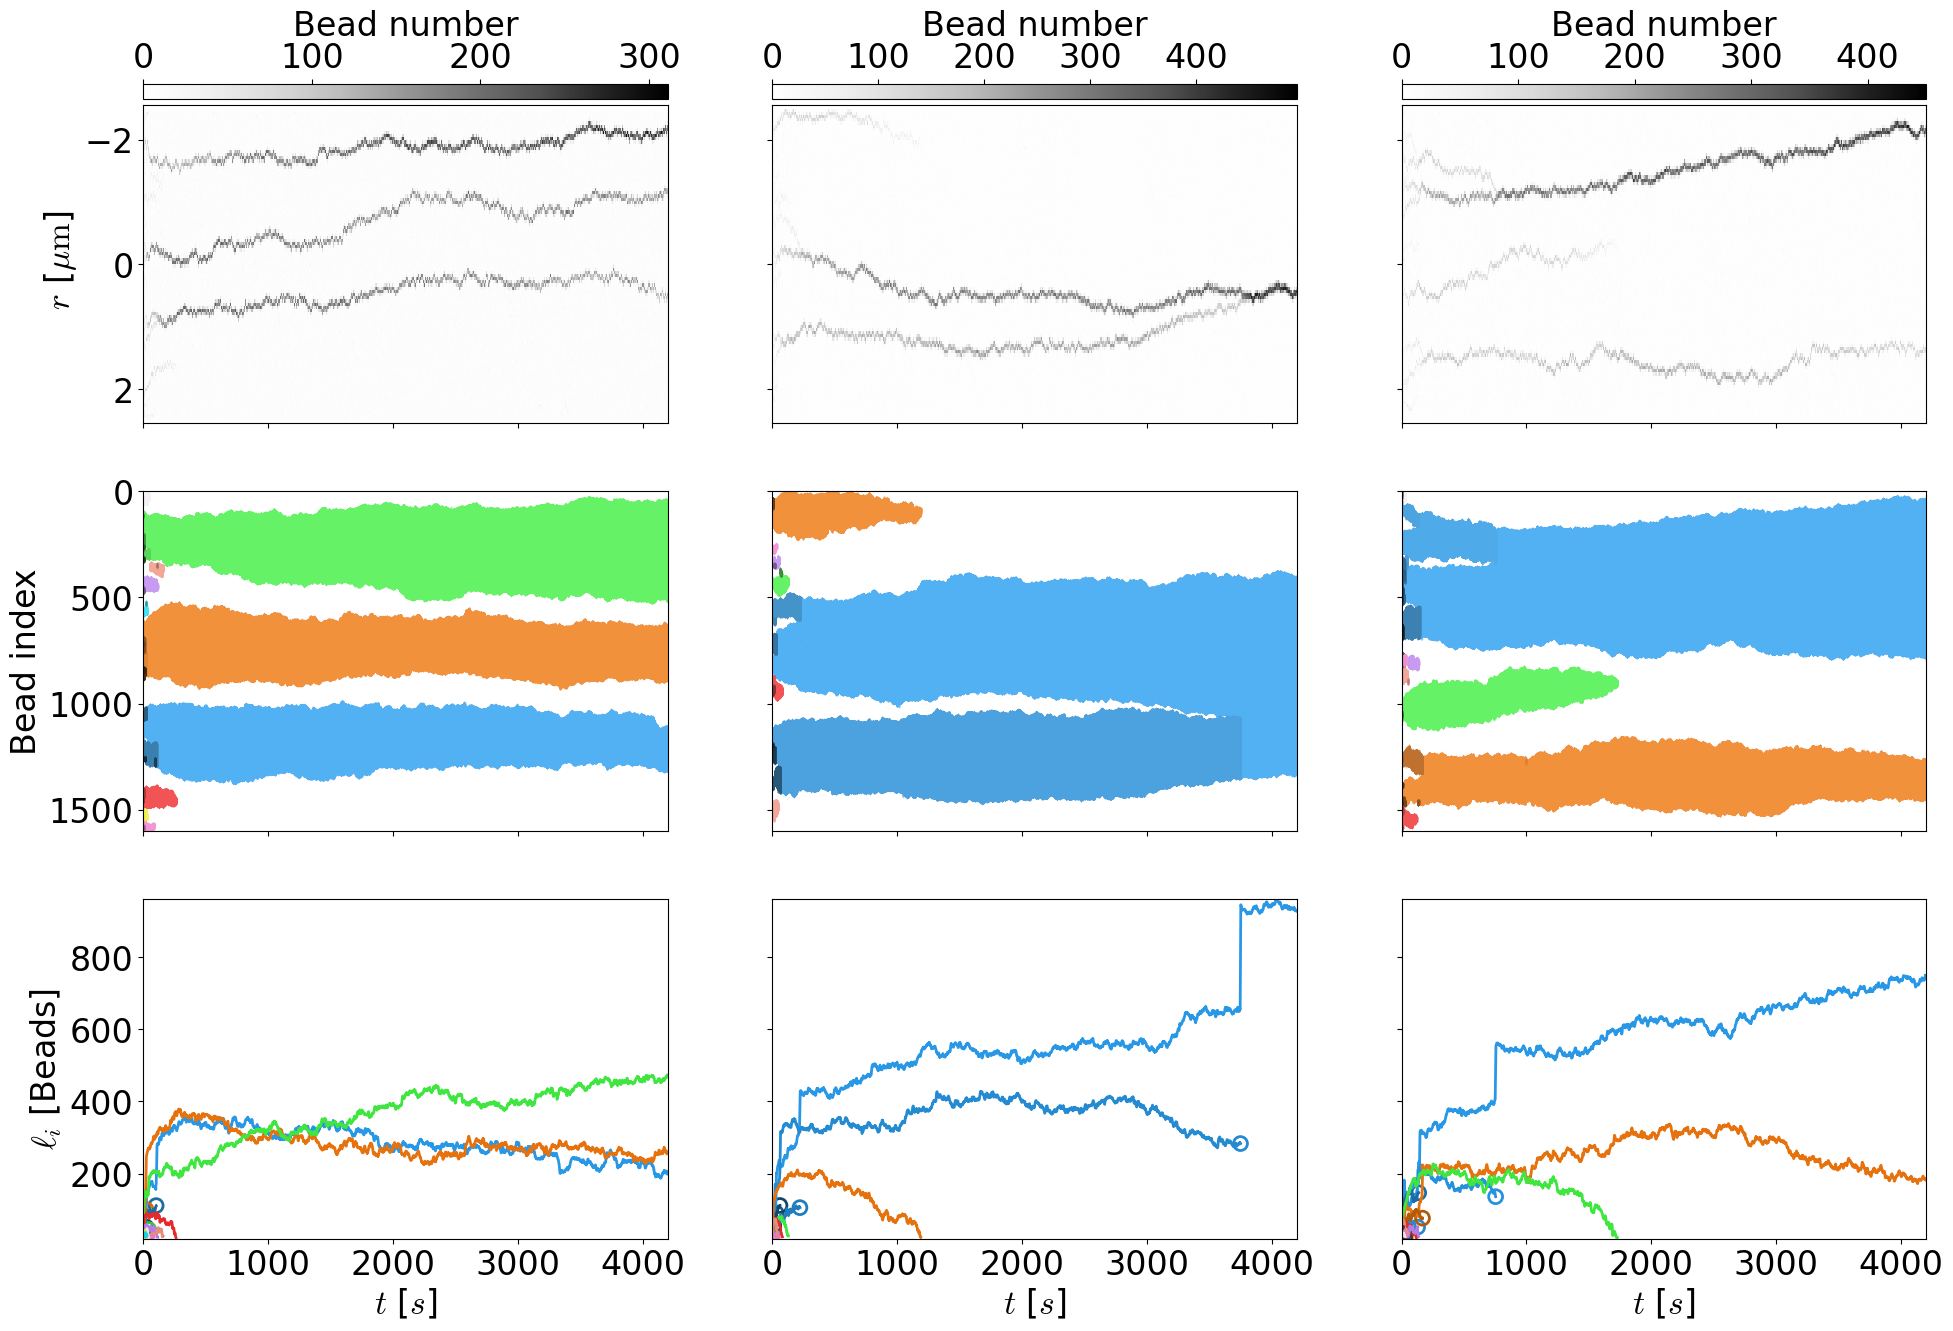

In [12]:
fig, axarr = plt.subplots(3, 3, figsize=(23, 15), sharex=True, sharey="row")
Ke = 30
Lsep = 5.0
s0 = 4
plot_kymo_contact_size_graphs(fig, axarr[:, 0], Ke, Lsep, s0, labels_on=True)
s1 = 6
plot_kymo_contact_size_graphs(fig, axarr[:, 1], Ke, Lsep, s1, labels_on=False)
s2 = 7
plot_kymo_contact_size_graphs(fig, axarr[:, 2], Ke, Lsep, s2, labels_on=False)

_ = axarr[0, 0].invert_yaxis()
_ = axarr[1, 0].invert_yaxis()

fig.savefig(
    f"SFig_tracking/fig_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s0}-{s1}-{s2}.png",
    dpi=600,
    bbox_inches="tight",
)
fig.savefig(
    f"SFig_tracking/fig_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s0}-{s1}-{s2}.pdf",
    dpi=600,
    bbox_inches="tight",
)
fig.savefig(
    f"/mnt/home/alamson/papers/dyn_cond_paper/images/SFig_tracking/fig_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s0}-{s1}-{s2}.png",
    dpi=600,
    bbox_inches="tight",
)
fig.savefig(
    f"/mnt/home/alamson/papers/dyn_cond_paper/images/SFig_tracking/fig_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s0}-{s1}-{s2}.pdf",
    dpi=600,
    bbox_inches="tight",
)


/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s8
(8401,)
[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.75607843 0.95      ]
[0.33333333 0.58       0.95      ]
[0.99904762 0.65420561 0.95      ]
[0.75387597 0.36402116 0.95      ]
[0.02820513 0.37142857 0.95      ]
[0.88425926 0.38061674 0.95      ]
[0.   0.   0.95]
[0.16774194 0.65608466 0.95      ]
[0.51539855 0.71111111 0.95      ]


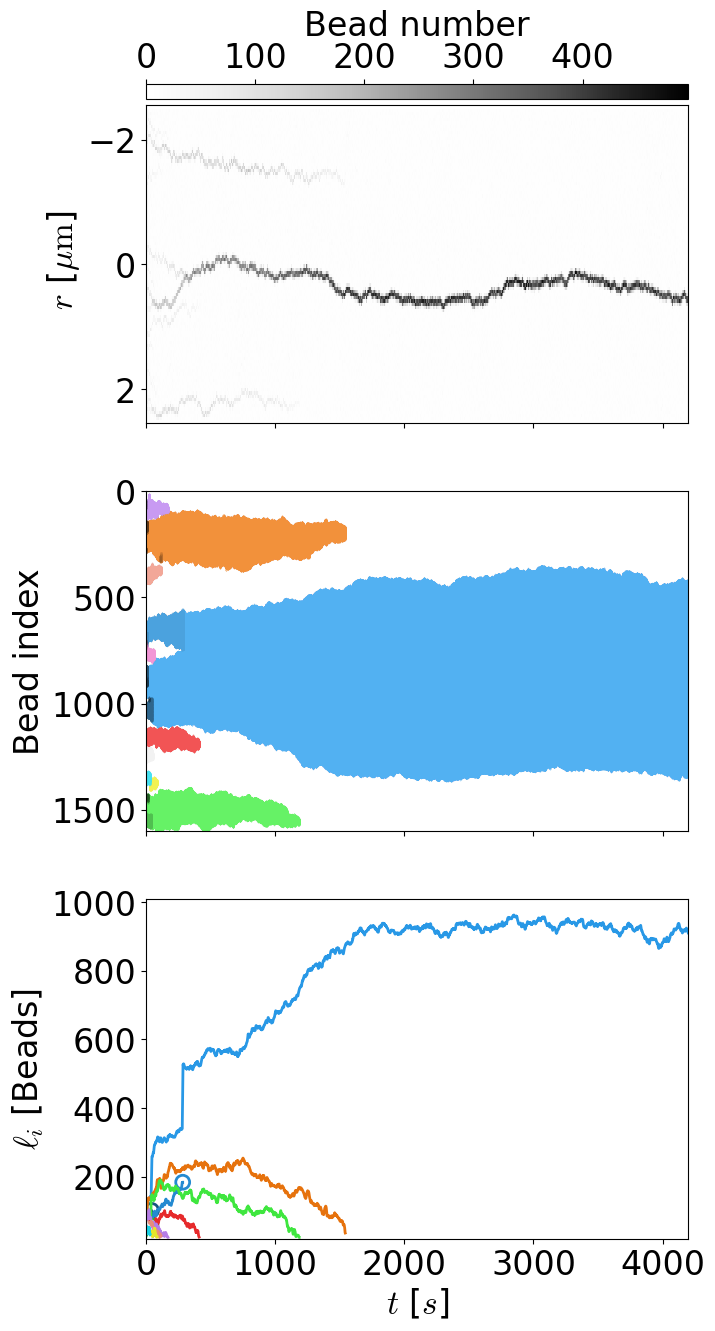

In [ ]:
fig, axarr = plt.subplots(3, 1, figsize=(7, 15), sharex=True)
Ke = 30
Lsep = 5.0
s = 8
plot_kymo_contact_size_graphs(fig, axarr, Ke, Lsep, s, labels_on=True)
axarr[0].invert_yaxis()
axarr[1].invert_yaxis()

# fig.savefig(
#     f"SFig_tracking/fig_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s}.png",
#     dpi=600,
#     bbox_inches="tight",
# )


## Lsep = 5.0um, Ke = 100

/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke100_Pin5.0um/s1
(8401,)
[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.75607843 0.95      ]
Skipping root
[0.33333333 0.58       0.95      ]
[0.99904762 0.65420561 0.95      ]
[0.75387597 0.36402116 0.95      ]
[0.02820513 0.37142857 0.95      ]
[0.88425926 0.38061674 0.95      ]
[0.   0.   0.95]
[0.16774194 0.65608466 0.95      ]
[0.51539855 0.71111111 0.95      ]
[0.56823266 0.66222222 0.95      ]
[0.07814661 0.75607843 0.95      ]
[0.33333333 0.58       0.95      ]
[0.99904762 0.65420561 0.95      ]
[0.75387597 0.36402116 0.95      ]


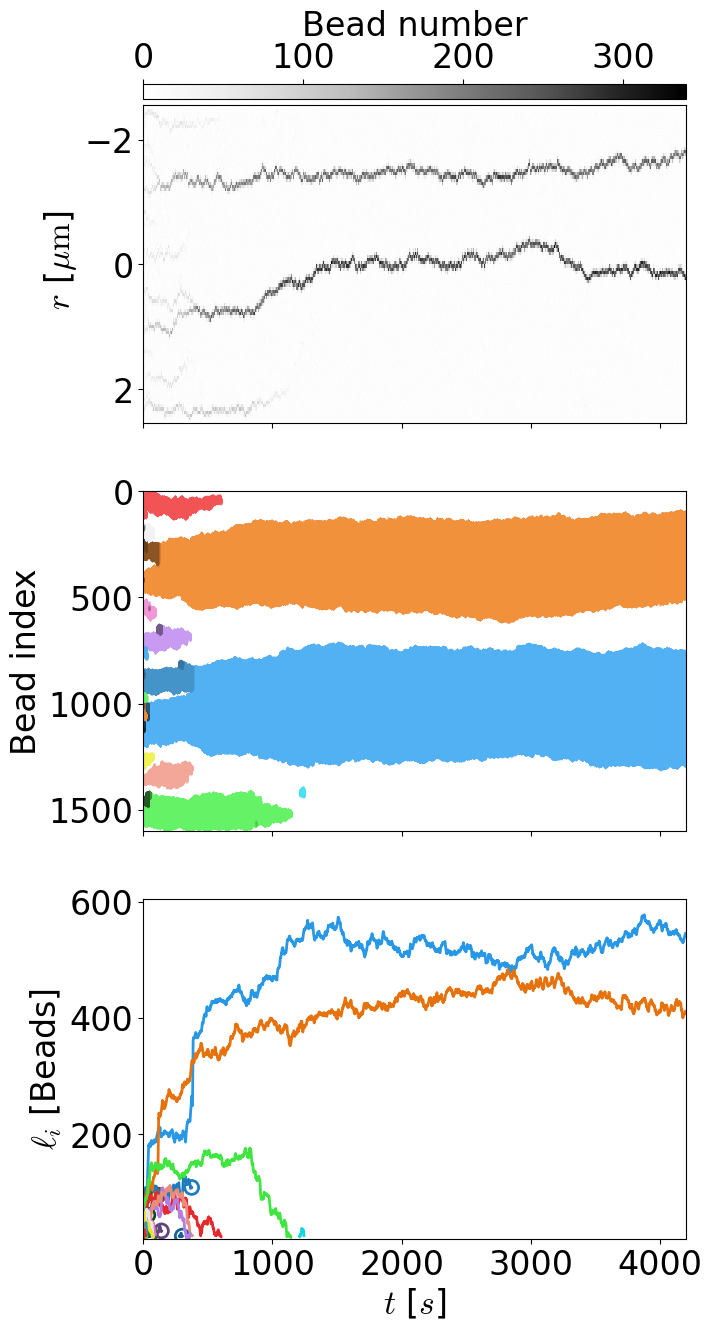

In [9]:
fig, axarr = plt.subplots(3, 1, figsize=(7, 15), sharex=True)
Ke = 100
Lsep = 5.0
s = 1
plot_kymo_contact_size_graphs(fig, axarr, Ke, Lsep, s, labels_on=True)
axarr[0].invert_yaxis()
axarr[1].invert_yaxis()

# fig.savefig(
#     f"Figure5/fig5_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s}.png",
#     dpi=600,
#     bbox_inches="tight",
# )


## Lsep = 3.0um, Ke = 30

/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin3.0um/s1
(8401,)


[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.75607843 0.95      ]
[0.33333333 0.58       0.95      ]
[0.99904762 0.65420561 0.95      ]


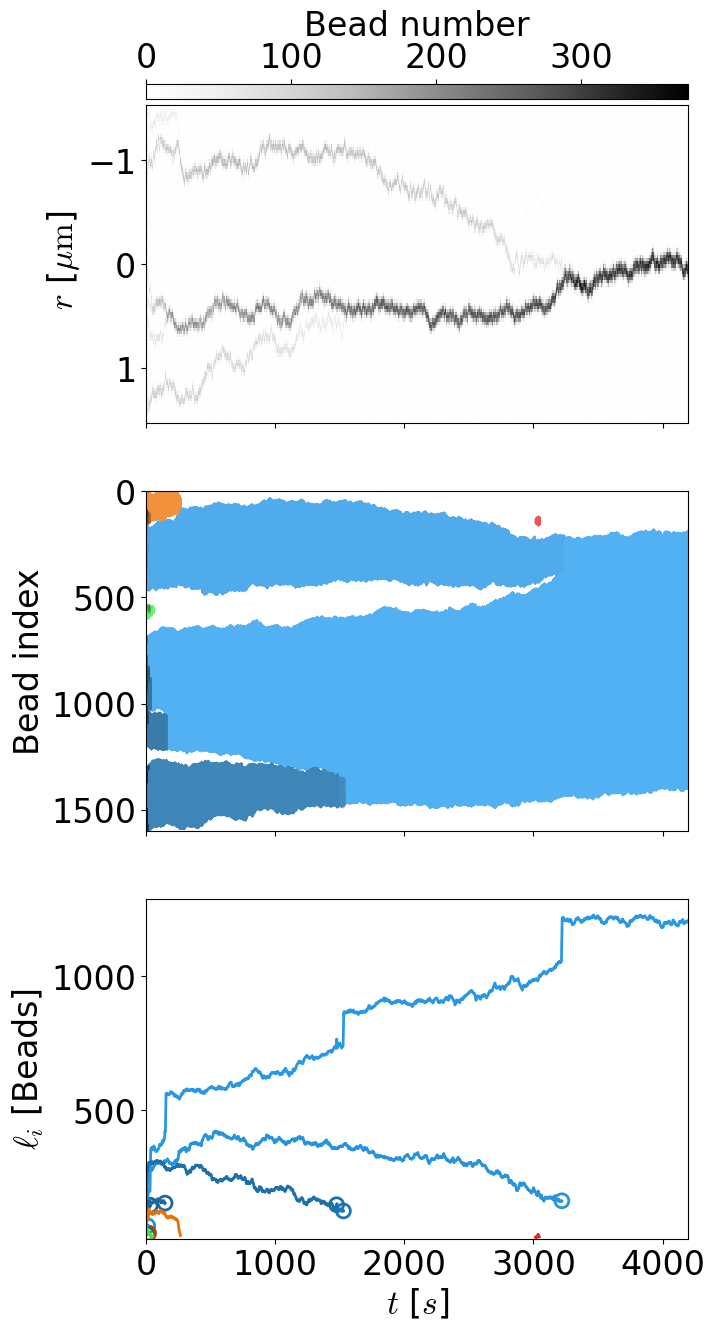

In [10]:
fig, axarr = plt.subplots(3, 1, figsize=(7, 15), sharex=True)
Ke = 30
Lsep = 3.0
s = 1
plot_kymo_contact_size_graphs(fig, axarr, Ke, Lsep, s, labels_on=True)
axarr[0].invert_yaxis()
axarr[1].invert_yaxis()

# fig.savefig(
#     f"Figure5/fig5_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s}.png",
#     dpi=600,
#     bbox_inches="tight",
# )


## Lsep = 3.0um, Ke = 100

/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke100_Pin3.0um/s1
(8401,)


[0.56823266 0.66222222 0.95      ]
Skipping root
[0.07814661 0.75607843 0.95      ]
Skipping root
[0.33333333 0.58       0.95      ]
[0.99904762 0.65420561 0.95      ]


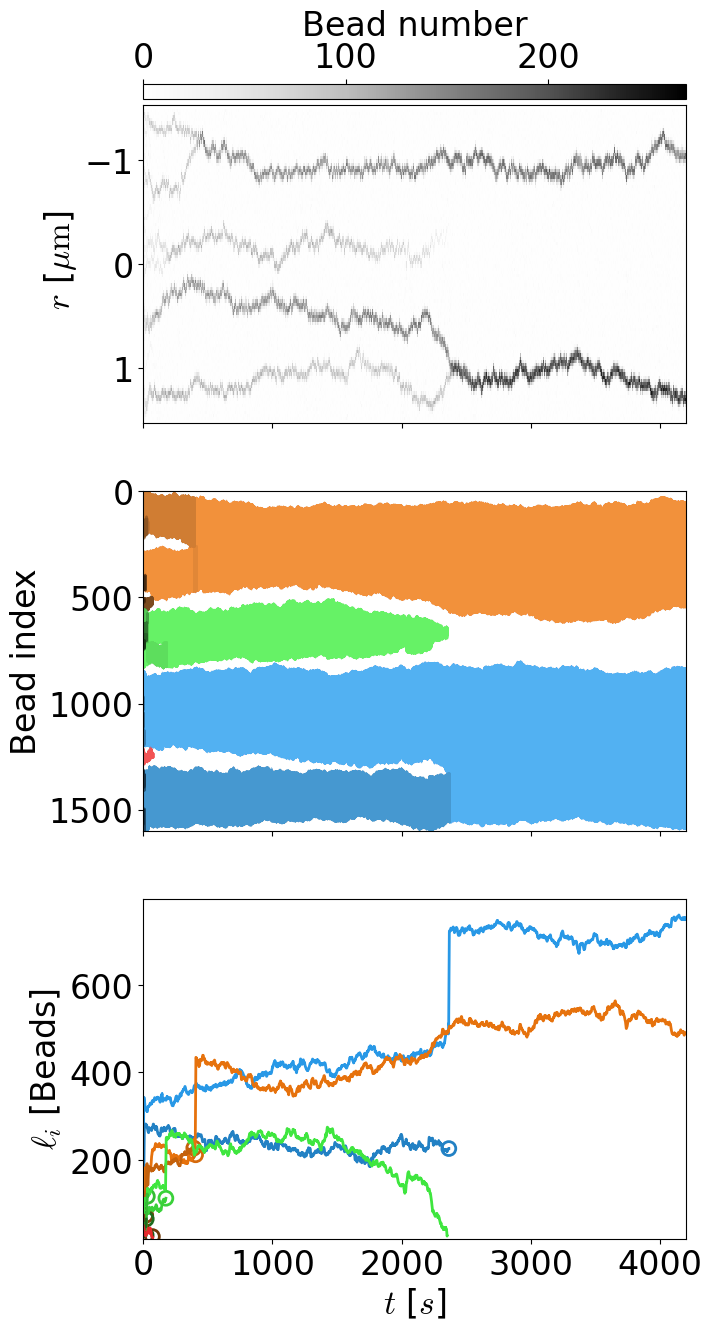

In [11]:
fig, axarr = plt.subplots(3, 1, figsize=(7, 15), sharex=True)
Ke = 100
Lsep = 3.0
s = 1
plot_kymo_contact_size_graphs(fig, axarr, Ke, Lsep, s, labels_on=True)
axarr[0].invert_yaxis()
axarr[1].invert_yaxis()

# fig.savefig(
#     f"Figure5/fig5_supp_tracking_Ke{Ke:d}_Lsep{Lsep:.0f}_s{s}.png",
#     dpi=600,
#     bbox_inches="tight",
# )
